# Graphene Raman Analysis — Hierarchical Dataset

**Expected folder layout:**
```
root/
  treatment-A/          ← level-1 subfolder  (e.g. halo, peg7-halo)
    sample-1/           ← level-2 subfolder  (e.g. 5a, 4b)
      D_01.txt
      D_02.txt  …       ← replicate spectra
    sample-2/ …
  treatment-B/ …
```

**Pipeline per spectrum:** ALS baseline correction → Savitzky–Golay smoothing → Lorentzian peak fitting (D, G, 2D) → I_D/I_G, I_2D/I_G

**Run order:** Cell 1 (setup) → Cell 2 (choose folder) → Cell 3 (analyse)

---
## Cell 1 — Setup (run once)

# Parameter Tuning Guide

## ALS Baseline — `ALS_LAMBDA` and `ALS_P`

The baseline is controlled by two numbers in Cell 1.

| Problem you see | What to change |
|---|---|
| Baseline follows the peaks (too flexible) | Increase `ALS_LAMBDA` → try `1e6` or `1e7` |
| Baseline sits too high above the valleys | Decrease `ALS_LAMBDA` → try `1e4` |
| Baseline cuts into peak feet | Increase `ALS_P` → try `0.05` or `0.1` |
| Baseline still too high after correction | Decrease `ALS_P` → try `0.001` |

**Quick rule of thumb:**
- `ALS_LAMBDA` controls *smoothness* — think of it as how stiff the baseline is
- `ALS_P` controls *asymmetry* — how much the baseline is pulled down toward the valleys

Typical starting ranges for Raman on graphene:
```python
ALS_LAMBDA = 1e4   # very flexible baseline
ALS_LAMBDA = 1e5   # default — good for moderate fluorescence
ALS_LAMBDA = 1e6   # stiff — good for slowly varying background
ALS_LAMBDA = 1e7   # very stiff — nearly flat baseline

ALS_P = 0.001   # baseline hugs the very bottom
ALS_P = 0.01    # default
ALS_P = 0.05    # baseline sits slightly higher
```

---

## Peak Fitting — `D_WINDOW`, `G_WINDOW`, `TWOD_WINDOW`

Each window `(low, high)` defines the wavenumber range used to fit that peak.
If the fit misses the peak or fits noise instead, **narrow or shift the window** to enclose only that peak.

| Problem you see | What to change |
|---|---|
| Fit curve lands on the wrong peak | Shift the window center toward the real peak |
| Fit is too wide / catches a neighbour | Narrow the window (reduce the range) |
| Fit fails (`nan`) | Widen the window slightly so more points are included |
| D′ band (~1620 cm⁻¹) merges into G fit | Narrow `G_WINDOW` to `(1530, 1600)` |

**Typical graphene peak positions for reference:**
```python
D_WINDOW    = (1280, 1420)   # D  band  ~1350 cm⁻¹
G_WINDOW    = (1520, 1640)   # G  band  ~1580 cm⁻¹
TWOD_WINDOW = (2600, 2800)   # 2D band  ~2680 cm⁻¹
```

---

## Smoothing — `SG_WINDOW` and `SG_ORDER`

| Problem you see | What to change |
|---|---|
| Spectrum still looks noisy after smoothing | Increase `SG_WINDOW` → try `15` or `21` |
| Peaks are being broadened / flattened | Decrease `SG_WINDOW` → try `7` |

`SG_WINDOW` must always be an **odd number**.  `SG_ORDER = 3` is almost always fine.

---

## Quick test cell

After changing any parameter in Cell 1, run the cell below to inspect **one spectrum** before re-running the full analysis:

Testing: D_02.txt


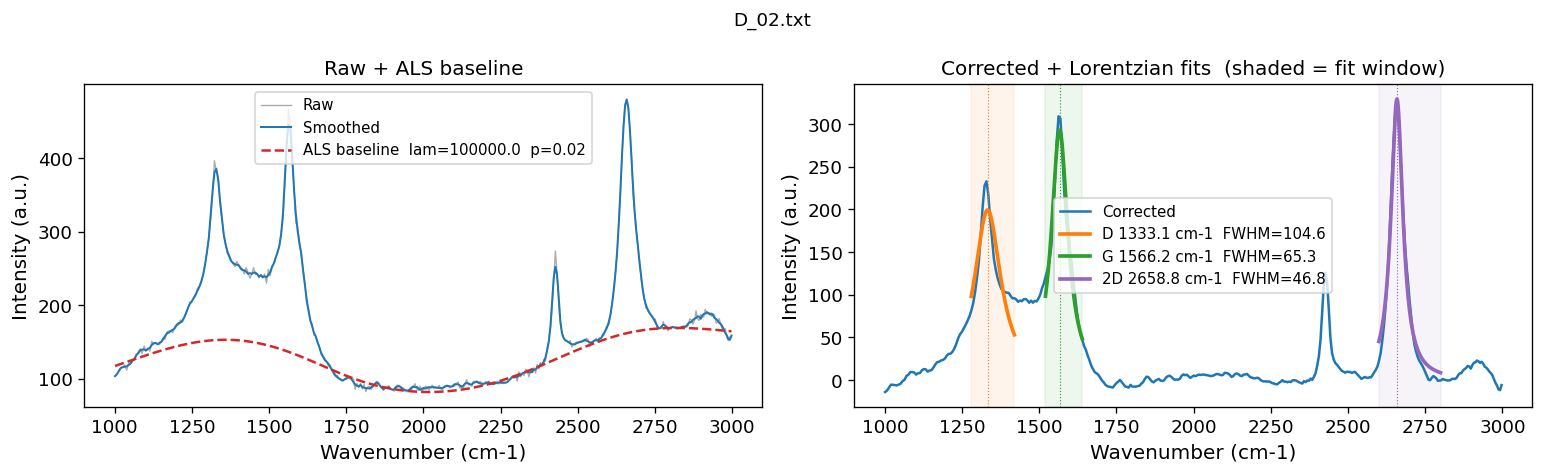

  D    1333.1 cm-1   FWHM 104.6   fit= True
  G    1566.2 cm-1   FWHM 65.3   fit= True
  2D   2658.8 cm-1   FWHM 46.8   fit= True
  ID/IG  = 0.6809
  I2D/IG = 1.1244


In [37]:
# ── Quick single-spectrum test ────────────────────────────────────────────────
# Change TEST_FILE to any .txt path you want to inspect.
# Re-run this cell after adjusting parameters in Cell 1 to see the effect immediately.

TEST_FILE = list(ROOT.rglob('*.txt'))[0]   # auto-picks first file; change if needed
print('Testing:', TEST_FILE.relative_to(ROOT))

r  = process_spectrum(TEST_FILE)
wn, raw, smooth, base, corr = r['wn'], r['raw'], r['smooth'], r['baseline'], r['corrected']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: raw + baseline
ax = axes[0]
ax.plot(wn, raw,    color='#aaa', lw=0.8, label='Raw')
ax.plot(wn, smooth, color='C0',   lw=1.2, label='Smoothed')
ax.plot(wn, base,   color='C3',   lw=1.5, ls='--',
        label='ALS baseline  lam=' + str(ALS_LAMBDA) + '  p=' + str(ALS_P))
ax.set_xlabel('Wavenumber (cm-1)'); ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Raw + ALS baseline'); ax.legend()

# Right: corrected + fits
ax = axes[1]
ax.plot(wn, corr, color='C0', lw=1.5, label='Corrected')
xf = np.linspace(wn.min(), wn.max(), 3000)
for name, fit, win, col in [
    ('D',  r['D'],    D_WINDOW,    'C1'),
    ('G',  r['G'],    G_WINDOW,    'C2'),
    ('2D', r['TwoD'], TWOD_WINDOW, 'C4'),
]:
    ax.axvspan(win[0], win[1], alpha=0.08, color=col)
    if fit['success']:
        xw  = xf[(xf >= win[0]) & (xf <= win[1])]
        pos = fit['position']
        fw  = fit['fwhm']
        lbl = name + ' ' + str(round(pos, 1)) + ' cm-1  FWHM=' + str(round(fw, 1))
        ax.plot(xw, lorentzian(xw, fit['amplitude'], pos, fw / 2),
                color=col, lw=2.2, label=lbl)
        ax.axvline(pos, color=col, lw=0.7, ls=':')
    else:
        ax.text((win[0]+win[1])/2, corr.max()*0.8, name + '\nfit failed',
                ha='center', color=col, fontsize=9)

ax.set_xlabel('Wavenumber (cm-1)'); ax.set_ylabel('Intensity (a.u.)')
ax.set_title('Corrected + Lorentzian fits  (shaded = fit window)')
ax.legend(fontsize=9)
plt.suptitle(str(TEST_FILE.relative_to(ROOT)), fontsize=11)
plt.tight_layout()
plt.show()

D, G, TD = r['D'], r['G'], r['TwoD']
print('  D   ', round(D['position'], 1), 'cm-1   FWHM', round(D['fwhm'], 1), '  fit=', D['success'])
print('  G   ', round(G['position'], 1), 'cm-1   FWHM', round(G['fwhm'], 1), '  fit=', G['success'])
print('  2D  ', round(TD['position'], 1), 'cm-1   FWHM', round(TD['fwhm'], 1), '  fit=', TD['success'])
print('  ID/IG  =', round(r['ID_IG'],  4))
print('  I2D/IG =', round(r['I2D_IG'], 4))

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, re
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 11,
    'axes.labelsize': 12, 'axes.titlesize': 12,
    'legend.fontsize': 9,
})

# ── Parameters — edit here if needed ─────────────────────────────────────────
SG_WINDOW   = 7       # Savitzky-Golay window (odd number)
SG_ORDER    = 3        # Savitzky-Golay polynomial order
ALS_LAMBDA  = 1e5      # ALS smoothness  (higher → flatter baseline)
ALS_P       = 0.02     # ALS asymmetry   (lower  → baseline hugs valleys)
ALS_NITER   = 20       # ALS iterations
D_WINDOW    = (1280, 1420)   # D  band fit range (cm⁻¹)
G_WINDOW    = (1520, 1640)   # G  band fit range
TWOD_WINDOW = (2600, 2800)   # 2D band fit range

# ─────────────────────────────────────────────────────────────────────────────
# Core functions
# ─────────────────────────────────────────────────────────────────────────────

def load_spectrum(path):
    """Load a LabSpec txt file (# header lines, then wavenumber\tintensity)."""
    wn, inten = [], []
    with open(path, encoding='latin-1') as fh:
        for line in fh:
            if line.startswith('#'):
                continue
            parts = line.split()
            if len(parts) == 2:
                try:
                    wn.append(float(parts[0]))
                    inten.append(float(parts[1]))
                except ValueError:
                    pass
    wn, inten = np.array(wn), np.array(inten)
    idx = np.argsort(wn)
    return wn[idx], inten[idx]


def als_baseline(y, lam=ALS_LAMBDA, p=ALS_P, niter=ALS_NITER):
    """Asymmetric Least Squares baseline (Eilers & Boelens 2005)."""
    n = len(y)
    D = diags([1, -2, 1], [0, 1, 2], shape=(n - 2, n))
    H = lam * D.T.dot(D)
    w = np.ones(n)
    for _ in range(niter):
        z = spsolve(diags(w, 0, shape=(n, n)) + H, w * y)
        w = np.where(y > z, p, 1 - p)
    return z


def lorentzian(x, amp, cen, wid):
    return amp * wid**2 / ((x - cen)**2 + wid**2)


def fit_peak(wn, corr, window):
    """Fit one Lorentzian inside window; return dict of peak parameters."""
    mask = (wn >= window[0]) & (wn <= window[1])
    x, y = wn[mask], corr[mask]
    nan_result = dict(position=np.nan, fwhm=np.nan, amplitude=np.nan,
                      area=np.nan, success=False)
    if len(x) < 5 or y.max() <= 0:
        return nan_result
    try:
        popt, _ = curve_fit(
            lorentzian, x, y,
            p0=[y.max(), x[np.argmax(y)], (window[1] - window[0]) / 4],
            bounds=([0, window[0], 1], [np.inf, window[1], window[1] - window[0]]),
            maxfev=5000)
        amp, cen, wid = popt
        return dict(position=cen, fwhm=2*wid, amplitude=amp,
                    area=np.pi*amp*wid, success=True)
    except Exception:
        return nan_result


def process_spectrum(path):
    """Full pipeline: load → smooth → ALS baseline → peak fits → ratios."""
    wn, raw = load_spectrum(path)
    win    = SG_WINDOW if SG_WINDOW % 2 == 1 else SG_WINDOW + 1
    smooth = savgol_filter(raw, window_length=win, polyorder=SG_ORDER)
    base   = als_baseline(smooth)
    corr   = smooth - base
    has_2d = wn.max() > 2600

    D  = fit_peak(wn, corr, D_WINDOW)
    G  = fit_peak(wn, corr, G_WINDOW)
    TD = fit_peak(wn, corr, TWOD_WINDOW) if has_2d else \
         dict(position=np.nan, fwhm=np.nan, amplitude=np.nan, area=np.nan, success=False)

    def ratio(a, b):
        return a / b if (b and b > 0 and not np.isnan(b)) else np.nan

    return dict(
        wn=wn, raw=raw, smooth=smooth, baseline=base, corrected=corr,
        D=D, G=G, TwoD=TD,
        ID_IG   = ratio(D['amplitude'],  G['amplitude']),
        I2D_IG  = ratio(TD['amplitude'], G['amplitude']),
        AD_AG   = ratio(D['area'],       G['area']),
    )


def scan_hierarchy(root):
    """
    Walk root/treatment/sample/*.txt and return a nested dict:
      { treatment: { sample: [Path, ...] } }
    """
    tree = {}
    for txt in sorted(root.rglob('*.txt')):
        parts = txt.relative_to(root).parts
        if len(parts) == 3:                # treatment / sample / file.txt
            treatment, sample = parts[0], parts[1]
        elif len(parts) == 2:              # sample / file.txt  (flat one level)
            treatment, sample = 'default', parts[0]
        elif len(parts) == 1:              # file.txt  (flat)
            treatment, sample = 'default', 'default'
        else:
            continue                       # deeper nesting — skip
        tree.setdefault(treatment, {}).setdefault(sample, []).append(txt)
    # sort files within each sample
    for t in tree:
        for s in tree[t]:
            tree[t][s].sort()
    return tree


print('✓  Setup complete — proceed to Cell 2.')

✓  Setup complete — proceed to Cell 2.


---
## Cell 2 — Choose root folder
Paste the path to the **root folder** (the one containing your treatment sub-folders), then press **Enter**.

In [17]:
raw_input = input('Paste root folder path, then press Enter:  ')
ROOT = Path(raw_input.strip().strip("'\"").replace('\\ ', ' '))

if not ROOT.exists():
    raise FileNotFoundError(f'Not found: {ROOT}')

TREE = scan_hierarchy(ROOT)
OUTPUT_DIR = ROOT / 'output'
OUTPUT_DIR.mkdir(exist_ok=True)

total = sum(len(files) for t in TREE for files in TREE[t].values())
print(f'\n📂  {ROOT}')
print(f'    {len(TREE)} treatment(s)  |  '
      f'{sum(len(TREE[t]) for t in TREE)} sample(s)  |  '
      f'{total} spectra\n')
for treatment, samples in TREE.items():
    print(f'  [{treatment}]')
    for sample, files in samples.items():
        names = ', '.join(f.name for f in files)
        print(f'    {sample:12s}  →  {names}')

Paste root folder path, then press Enter:   halo/5a



📂  halo/5a
    1 treatment(s)  |  1 sample(s)  |  3 spectra

  [default]
    default       →  D_01.txt, D_02.txt, D_03.txt


---
## Cell 3 — Full analysis
For every spectrum: ALS baseline → smoothing → Lorentzian fits → plots.  
Then per-sample averages, cross-treatment comparisons, and a summary CSV.


════════════════════════════════════════════════════════════
  TREATMENT: default
════════════════════════════════════════════════════════════

  ── Sample: default  (3 replicate(s))


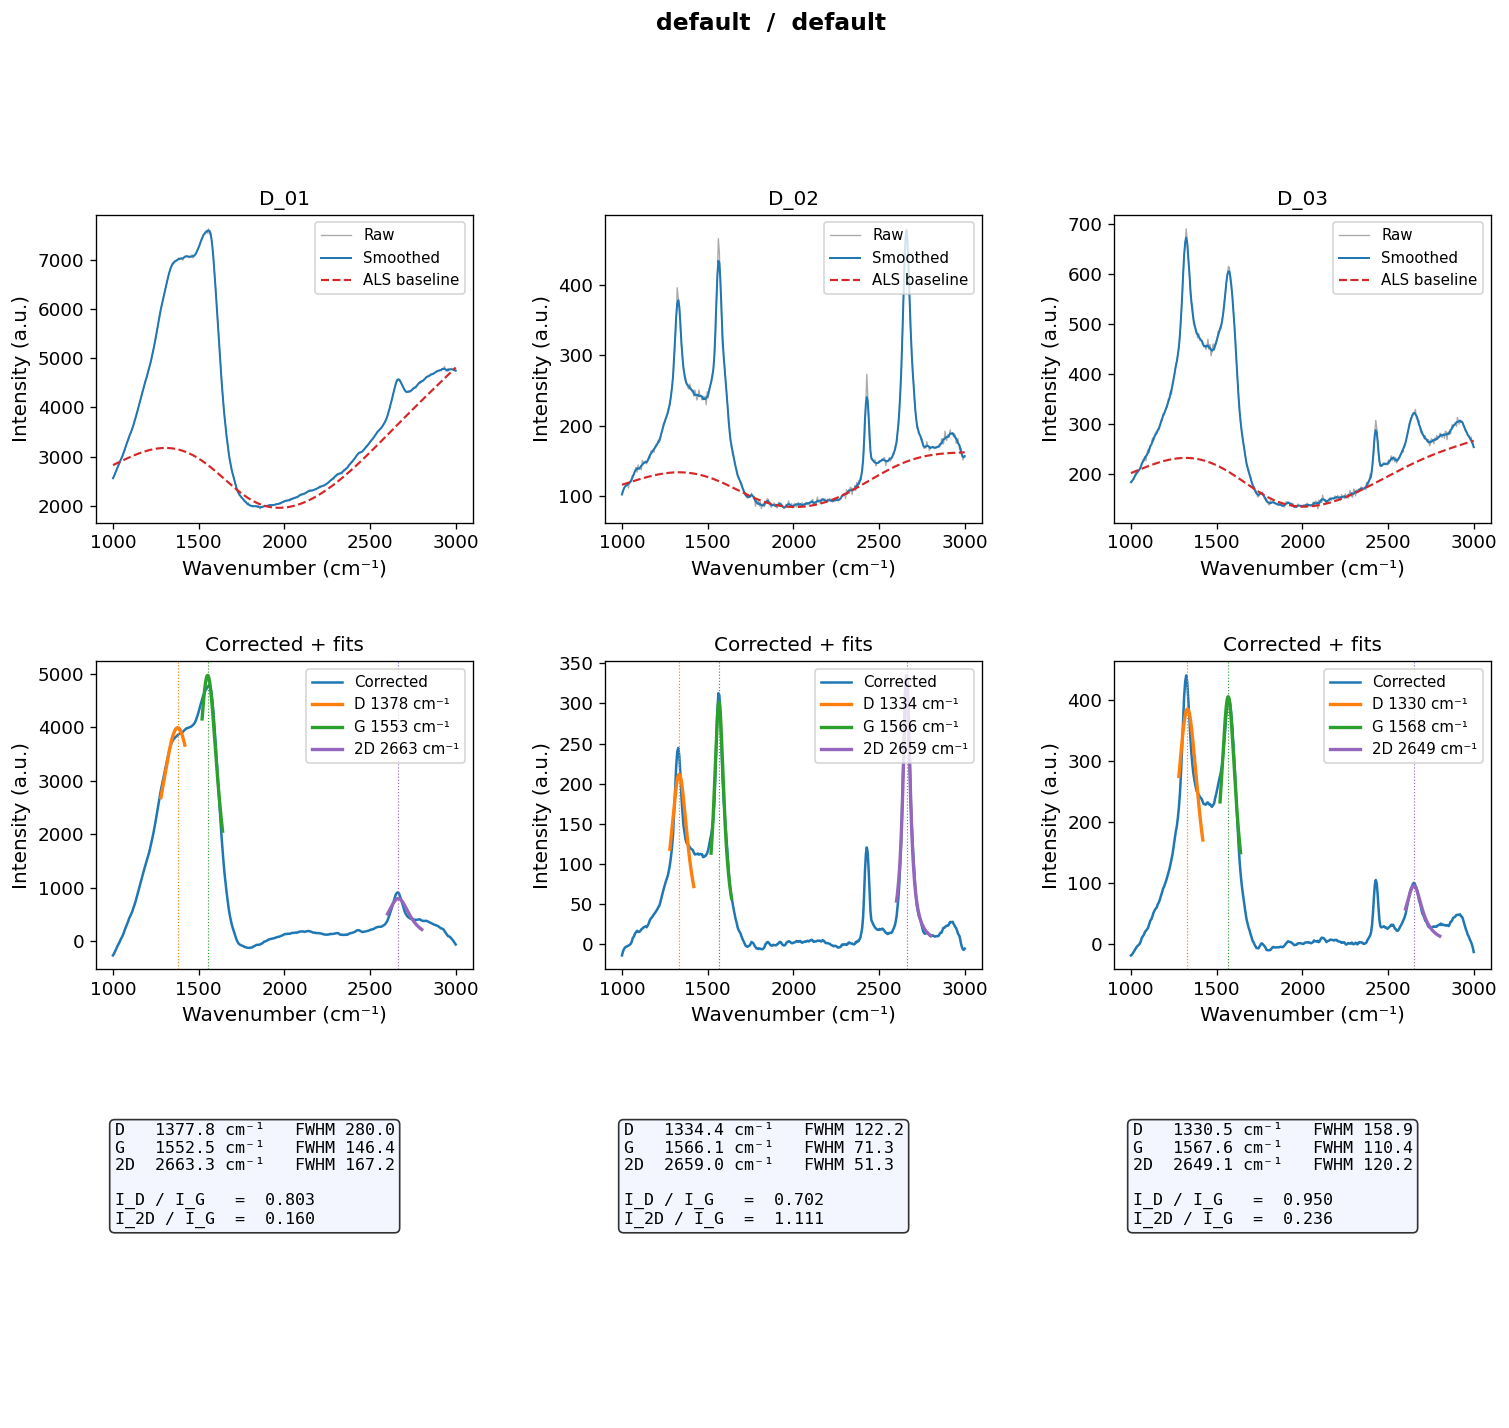

    I_D/I_G  : 0.819 ± 0.102
    I_2D/I_G : 0.502 ± 0.431


In [18]:
# colour palette — one colour per treatment
TREATMENT_COLORS = plt.colormaps['tab10']
treatment_list = list(TREE.keys())
t_color = {t: TREATMENT_COLORS(i / max(len(treatment_list)-1, 1))
           for i, t in enumerate(treatment_list)}

all_rows = []   # collects one row per spectrum for the master CSV

# ══════════════════════════════════════════════════════════════════════════════
# LOOP — treatment → sample → replicates
# ══════════════════════════════════════════════════════════════════════════════
for treatment, samples in TREE.items():
    print(f'\n{"═"*60}')
    print(f'  TREATMENT: {treatment}')
    print(f'{"═"*60}')

    for sample, files in samples.items():
        print(f'\n  ── Sample: {sample}  ({len(files)} replicate(s))')
        results = []

        # ── process each replicate ─────────────────────────────────────────
        for f in files:
            try:
                r = process_spectrum(f)
                r['label'] = f.stem
                results.append(r)
                all_rows.append(dict(
                    treatment=treatment, sample=sample, file=f.name,
                    D_pos=r['D']['position'],   D_fwhm=r['D']['fwhm'],
                    D_amp=r['D']['amplitude'],
                    G_pos=r['G']['position'],   G_fwhm=r['G']['fwhm'],
                    G_amp=r['G']['amplitude'],
                    TwoD_pos=r['TwoD']['position'],  TwoD_fwhm=r['TwoD']['fwhm'],
                    TwoD_amp=r['TwoD']['amplitude'],
                    ID_IG=r['ID_IG'], I2D_IG=r['I2D_IG'],
                ))
            except Exception as e:
                print(f'    SKIP {f.name}: {e}')

        if not results:
            continue

        # ── Figure: one column per replicate, 3 rows ───────────────────────
        n_rep = len(results)
        fig = plt.figure(figsize=(5 * n_rep, 13))
        gs  = gridspec.GridSpec(3, n_rep, figure=fig, hspace=0.45, wspace=0.35)
        fig.suptitle(f'{treatment}  /  {sample}', fontsize=14, fontweight='bold', y=1.01)

        xf = np.linspace(1000, 3000, 4000)    # x for drawing fit curves
        fit_colors = {'D': 'C1', 'G': 'C2', '2D': 'C4'}

        for col, r in enumerate(results):
            wn, raw, smooth, base, corr = (
                r['wn'], r['raw'], r['smooth'], r['baseline'], r['corrected'])

            # Row 0 — raw + baseline
            ax0 = fig.add_subplot(gs[0, col])
            ax0.plot(wn, raw,    color='#aaa', lw=0.8, label='Raw')
            ax0.plot(wn, smooth, color='C0',   lw=1.2, label='Smoothed')
            ax0.plot(wn, base,   color='C3',   lw=1.3, ls='--', label='ALS baseline')
            ax0.set_title(r['label'])
            ax0.set_ylabel('Intensity (a.u.)')
            ax0.legend(loc='upper right')
            ax0.set_xlabel('Wavenumber (cm⁻¹)')

            # Row 1 — corrected + Lorentzian fits
            ax1 = fig.add_subplot(gs[1, col])
            ax1.plot(wn, corr, color='C0', lw=1.5, label='Corrected')
            for name, fit, win in [
                ('D',  r['D'],    D_WINDOW),
                ('G',  r['G'],    G_WINDOW),
                ('2D', r['TwoD'], TWOD_WINDOW),
            ]:
                if fit['success']:
                    xw = xf[(xf >= win[0]) & (xf <= win[1])]
                    ax1.plot(xw,
                             lorentzian(xw, fit['amplitude'],
                                        fit['position'], fit['fwhm']/2),
                             color=fit_colors[name], lw=2.0,
                             label=f"{name} {fit['position']:.0f} cm⁻¹")
                    ax1.axvline(fit['position'],
                                color=fit_colors[name], lw=0.7, ls=':')
            ax1.set_ylabel('Intensity (a.u.)')
            ax1.set_xlabel('Wavenumber (cm⁻¹)')
            ax1.legend(loc='upper right')
            ax1.set_title('Corrected + fits')

            # Row 2 — peak ratio text card
            ax2 = fig.add_subplot(gs[2, col])
            ax2.axis('off')
            lines_txt = [
                f"D   {r['D']['position']:.1f} cm⁻¹   FWHM {r['D']['fwhm']:.1f}",
                f"G   {r['G']['position']:.1f} cm⁻¹   FWHM {r['G']['fwhm']:.1f}",
            ]
            if r['TwoD']['success']:
                lines_txt.append(
                    f"2D  {r['TwoD']['position']:.1f} cm⁻¹   FWHM {r['TwoD']['fwhm']:.1f}")
            lines_txt += [
                '',
                f"I_D / I_G   =  {r['ID_IG']:.3f}",
                f"I_2D / I_G  =  {r['I2D_IG']:.3f}" if not np.isnan(r['I2D_IG']) else 'I_2D / I_G  =  n/a',
            ]
            ax2.text(0.05, 0.95, '\n'.join(lines_txt),
                     transform=ax2.transAxes,
                     va='top', ha='left', fontsize=10,
                     fontfamily='monospace',
                     bbox=dict(boxstyle='round', facecolor='#f0f4ff', alpha=0.8))

        plt.tight_layout()
        save_path = OUTPUT_DIR / f'{treatment}_{sample}_spectra.png'
        fig.savefig(save_path, bbox_inches='tight', dpi=150)
        plt.show()

        # ── print per-sample mean ± std ────────────────────────────────────
        id_ig_vals  = [r['ID_IG']  for r in results if not np.isnan(r['ID_IG'])]
        i2d_ig_vals = [r['I2D_IG'] for r in results if not np.isnan(r['I2D_IG'])]
        print(f'    I_D/I_G  : {np.mean(id_ig_vals):.3f} ± {np.std(id_ig_vals):.3f}')
        if i2d_ig_vals:
            print(f'    I_2D/I_G : {np.mean(i2d_ig_vals):.3f} ± {np.std(i2d_ig_vals):.3f}')

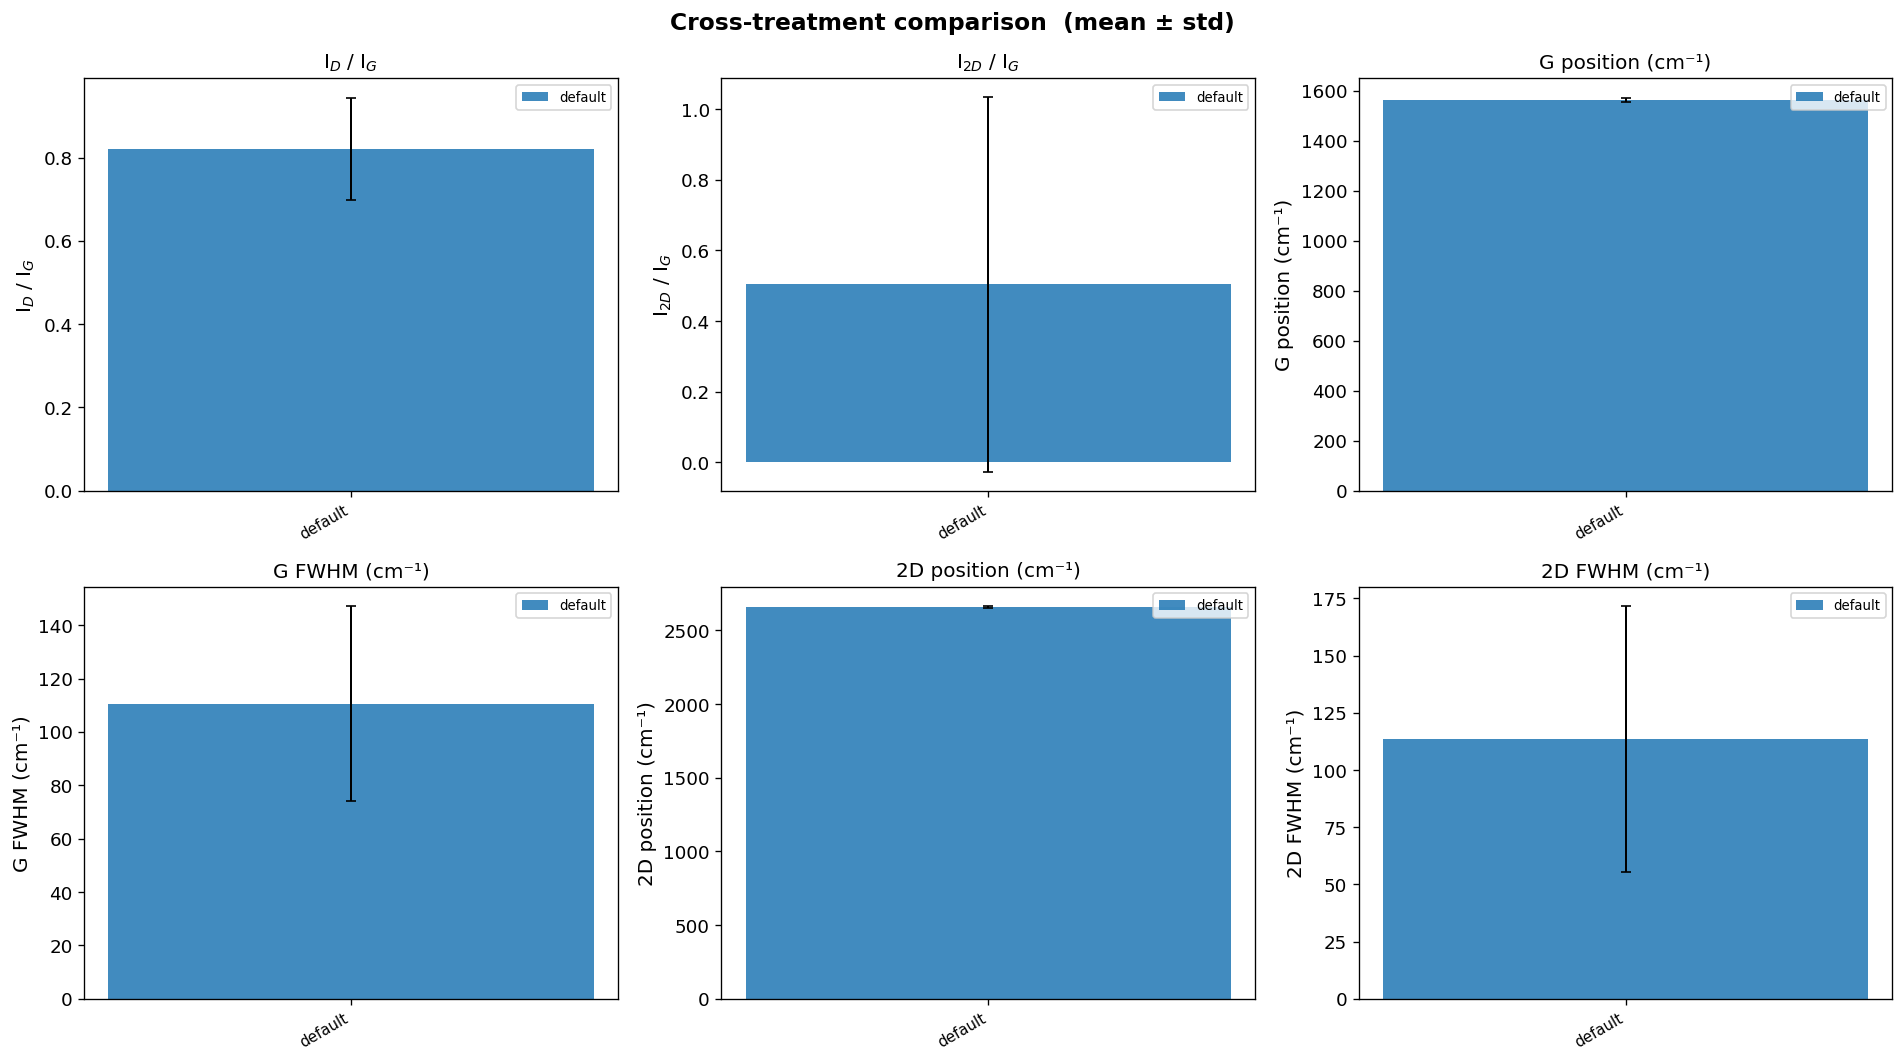

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# Cross-treatment comparison plots
# ══════════════════════════════════════════════════════════════════════════════
master = pd.DataFrame(all_rows)

# aggregate: mean ± std per (treatment, sample)
agg = (master
       .groupby(['treatment', 'sample'])[['ID_IG', 'I2D_IG', 'G_pos', 'G_fwhm',
                                          'TwoD_pos', 'TwoD_fwhm']]
       .agg(['mean', 'std'])
       .reset_index())
agg.columns = ['_'.join(c).strip('_') for c in agg.columns]

metrics = [
    ('ID_IG_mean',    'ID_IG_std',    'I$_D$ / I$_G$'),
    ('I2D_IG_mean',   'I2D_IG_std',   'I$_{2D}$ / I$_G$'),
    ('G_pos_mean',    'G_pos_std',    'G position (cm⁻¹)'),
    ('G_fwhm_mean',   'G_fwhm_std',   'G FWHM (cm⁻¹)'),
    ('TwoD_pos_mean', 'TwoD_pos_std', '2D position (cm⁻¹)'),
    ('TwoD_fwhm_mean','TwoD_fwhm_std','2D FWHM (cm⁻¹)'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Cross-treatment comparison  (mean ± std)', fontsize=14, fontweight='bold')

for ax, (mean_col, std_col, ylabel) in zip(axes.flatten(), metrics):
    for i, treatment in enumerate(treatment_list):
        sub = agg[agg['treatment'] == treatment]
        if sub.empty or mean_col not in sub.columns:
            continue
        x       = np.arange(len(sub))
        means   = sub[mean_col].values.astype(float)
        stds    = sub[std_col].values.astype(float) if std_col in sub.columns else np.zeros_like(means)
        offset  = (i - len(treatment_list)/2 + 0.5) * 0.8 / len(treatment_list)
        ax.bar(x + offset, means, width=0.8/len(treatment_list),
               color=t_color[treatment], alpha=0.85, label=treatment)
        ax.errorbar(x + offset, means, yerr=np.nan_to_num(stds),
                    fmt='none', color='k', capsize=3, lw=1.2)
        # sample labels only on first treatment to avoid clutter
        if i == 0:
            ax.set_xticks(x)
            ax.set_xticklabels(sub['sample'].values, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'cross_treatment_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

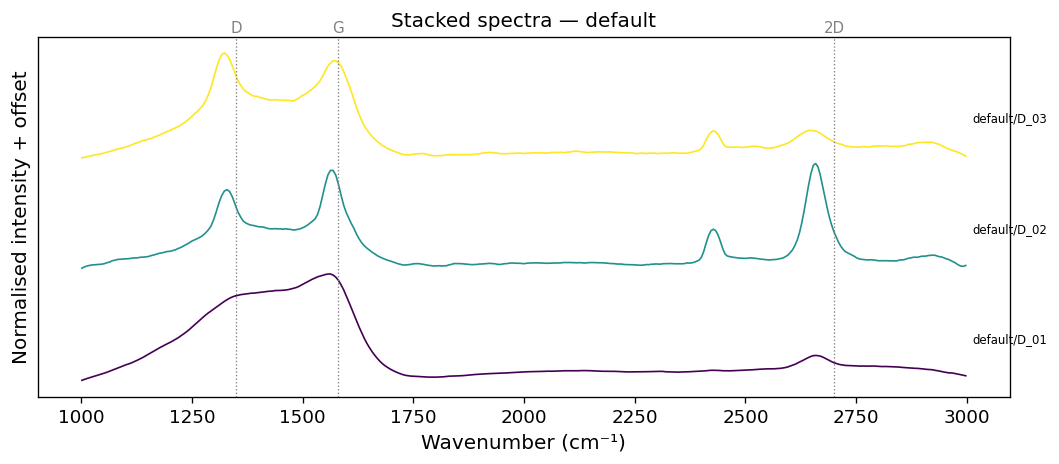

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# Stacked overlay — all corrected spectra, grouped by treatment
# ══════════════════════════════════════════════════════════════════════════════
for treatment, samples in TREE.items():
    all_res = []
    for sample, files in samples.items():
        for f in files:
            try:
                r = process_spectrum(f)
                r['label'] = f'{sample}/{f.stem}'
                all_res.append(r)
            except Exception:
                pass

    if not all_res:
        continue

    cmap = plt.colormaps['viridis']
    fig, ax = plt.subplots(figsize=(9, max(4, 1.1 * len(all_res))))
    off = 0
    for i, r in enumerate(all_res):
        y = r['corrected']
        y = y / y.max() if y.max() > 0 else y
        ax.plot(r['wn'], y + off,
                color=cmap(i / max(len(all_res)-1, 1)), lw=1.0)
        ax.text(r['wn'].max() * 1.005, off + 0.35,
                r['label'], fontsize=7, va='center')
        off += 1.1

    for xv, lb in [(1350,'D'), (1580,'G'), (2700,'2D')]:
        if all_res[0]['wn'].min() < xv < all_res[0]['wn'].max():
            ax.axvline(xv, ls=':', color='grey', lw=0.8)
            ax.text(xv, off + 0.1, lb, ha='center', fontsize=9, color='grey')

    ax.set_xlabel('Wavenumber (cm⁻¹)')
    ax.set_ylabel('Normalised intensity + offset')
    ax.set_title(f'Stacked spectra — {treatment}')
    ax.set_yticks([])
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / f'{treatment}_stack.png', bbox_inches='tight')
    plt.show()

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# Save summary CSVs
# ══════════════════════════════════════════════════════════════════════════════

# All individual spectra
master.to_csv(OUTPUT_DIR / 'all_spectra_summary.csv', index=False, float_format='%.4f')

# Aggregated mean ± std per (treatment, sample)
agg.to_csv(OUTPUT_DIR / 'sample_mean_std.csv', index=False, float_format='%.4f')

print(f'✓  All outputs saved to:  {OUTPUT_DIR}\n')
print('Individual spectra table:')
display(master.round(3))
print('\nAggregated (mean ± std) per sample:')
display(agg.round(3))

✓  All outputs saved to:  halo/5a/output

Individual spectra table:


,treatment,sample,file,D_pos,D_fwhm,D_amp,G_pos,G_fwhm,G_amp,TwoD_pos,TwoD_fwhm,TwoD_amp,ID_IG,I2D_IG
0,default,default,D_01.txt,1377.881,280.000,3991.533,1552.442,146.670,4967.061,2663.282,167.729,796.609,0.804,0.160
1,default,default,D_02.txt,1334.411,123.869,210.585,1566.012,73.580,297.046,2659.059,52.285,331.051,0.709,1.114
2,default,default,D_03.txt,1330.347,160.401,385.058,1567.417,111.342,404.954,2649.098,120.667,95.491,0.951,0.236



Aggregated (mean ± std) per sample:


,treatment,sample,ID_IG_mean,ID_IG_std,I2D_IG_mean,I2D_IG_std,G_pos_mean,G_pos_std,G_fwhm_mean,G_fwhm_std,TwoD_pos_mean,TwoD_pos_std,TwoD_fwhm_mean,TwoD_fwhm_std
0,default,default,0.821,0.122,0.504,0.53,1561.957,8.27,110.531,36.552,2657.146,7.283,113.561,58.049
